## **Project: Diabetes Detection System**

**Project Overview**

- Build a binary classification model that predicts whether a person has diabetes or not based on medical features.

## Load data from the given file

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
# Load dataset from Seaborn or URL
url = '/content/sample_data/diabetes-dataset.csv'
diabetes_df = pd.read_csv(url)
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Filter and EDA with the given data

In [ ]:
diabetes_df.shape

(768, 9)

In [ ]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
diabetes_df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
diabetes_df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# Train and test split data and create Confusion Matrix for four models without scaling the data

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import numpy as np

In [ ]:
# Load dataset
data = diabetes_df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']]

In [ ]:
# Train-test split
X = data.drop('Outcome', axis=1)
y = data['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n🔍 Confusion Matrix for {name}:")
    print(cm)
    print(classification_report(y_test, y_pred))
    results[name] = (model, y_pred)


🔍 Confusion Matrix for Logistic Regression:
[[78 21]
 [18 37]]
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154


🔍 Confusion Matrix for KNN:
[[70 29]
 [23 32]]
              precision    recall  f1-score   support

           0       0.75      0.71      0.73        99
           1       0.52      0.58      0.55        55

    accuracy                           0.66       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.66      0.67       154


🔍 Confusion Matrix for Random Forest:
[[77 22]
 [19 36]]
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        99
           1       0.62      0.65      0.64        55

    accuracy

Logistic Regression:

    Confusion Matrix:
        True Negatives (TN): 78 (Correctly predicted as no diabetes)
        False Positives (FP): 21 (Incorrectly predicted as having diabetes)
        False Negatives (FN): 18 (Incorrectly predicted as no diabetes)
        True Positives (TP): 37 (Correctly predicted as having diabetes)
    Precision (Class 1 - Diabetes): 0.64. This means when the Logistic Regression model predicts someone has diabetes, it is correct 64% of the time.
    Recall (Class 1 - Diabetes): 0.67. This means the Logistic Regression model correctly identifies 67% of the people who actually have diabetes.
    F1-score (Class 1 - Diabetes): 0.65.
    Accuracy: 0.75. Overall, the model is correct 75% of the time.

K-Nearest Neighbors (KNN):

    Confusion Matrix:
        TN: 70
        FP: 29
        FN: 23
        TP: 32
    Precision (Class 1 - Diabetes): 0.52. When KNN predicts someone has diabetes, it's correct 52% of the time.
    Recall (Class 1 - Diabetes): 0.58. KNN correctly identifies 58% of people with diabetes.
    F1-score (Class 1 - Diabetes): 0.55.
    Accuracy: 0.66. KNN has the lowest overall accuracy among the models tested.

Random Forest:

    Confusion Matrix:
        TN: 77
        FP: 22
        FN: 19
        TP: 36
    Precision (Class 1 - Diabetes): 0.62. When Random Forest predicts someone has diabetes, it's correct 62% of the time.
    Recall (Class 1 - Diabetes): 0.65. Random Forest correctly identifies 65% of people with diabetes.
    F1-score (Class 1 - Diabetes): 0.64.
    Accuracy: 0.73.

Decision Tree:

    Confusion Matrix:
        TN: 73
        FP: 26
        FN: 15
        TP: 40
    Precision (Class 1 - Diabetes): 0.61. When Decision Tree predicts someone has diabetes, it's correct 61% of the time.
    Recall (Class 1 - Diabetes): 0.73. Decision Tree has the highest recall for identifying people with diabetes (73%).
    F1-score (Class 1 - Diabetes): 0.66.
    Accuracy: 0.73.

Summary and Comparison:

    Logistic Regression has the highest overall accuracy (0.75) and a good balance of precision and recall for the positive class.
    Decision Tree has the highest recall for the positive class (0.73), meaning it's best at identifying actual diabetes cases, but it also has more false positives than Logistic Regression.
    Random Forest performs similarly to Logistic Regression in terms of accuracy, precision, and recall.
    KNN has the lowest performance across most metrics.

The choice of the "best" model depends on the specific goals of the diabetes detection system. If minimizing false negatives (missing actual diabetes cases) is the priority, the Decision Tree might be preferred due to its higher recall. If minimizing false positives (incorrectly diagnosing someone with diabetes) is more important, Logistic Regression or Random Forest might be better choices due to their higher precision.

Next steps could include:

    Visualizing the ROC curves and calculating AUC for each model to further compare their ability to distinguish between the classes.
    Applying feature scaling to see if it improves the performance of models sensitive to feature ranges (like KNN and Logistic Regression).
    Tuning the hyperparameters of the models to potentially improve their performance.
    Considering other classification algorithms.



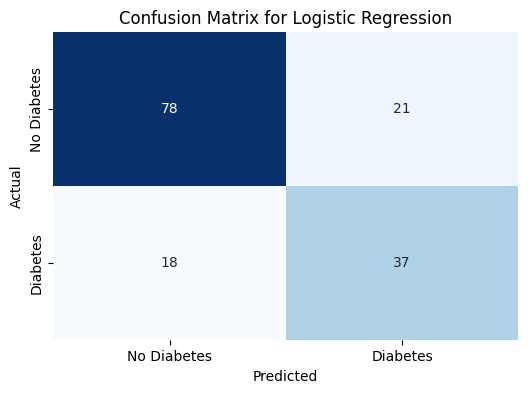

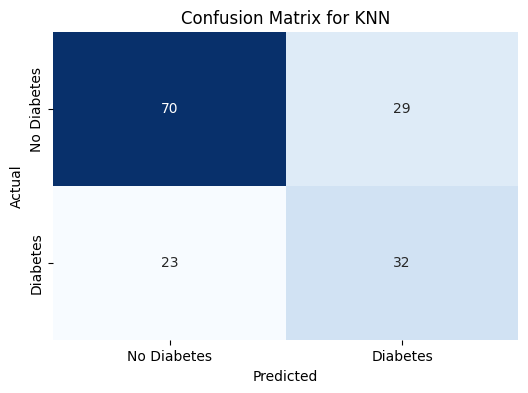

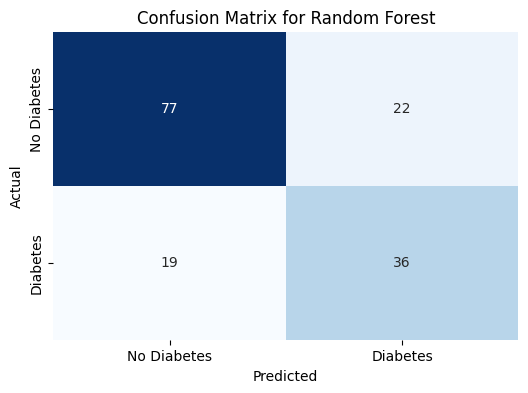

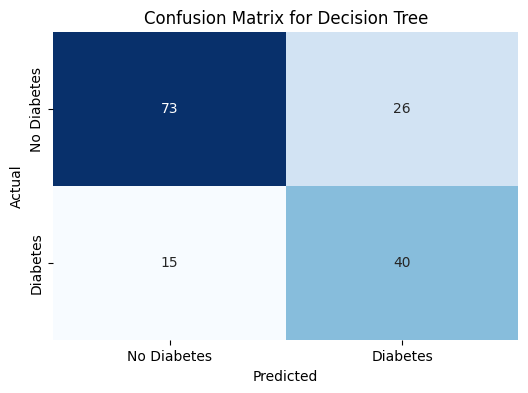

In [ ]:
# Visualize Confusion Matrices as Heatmaps
for name, (model, y_pred) in results.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

## Create ROC curves

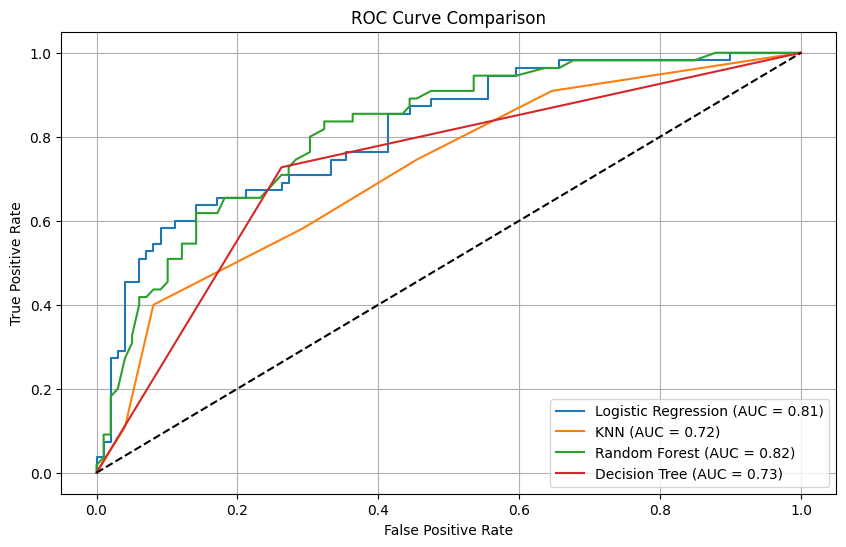

In [ ]:
# Plot ROC curves
plt.figure(figsize=(10, 6))
for name, (model, _) in results.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()
plt.show()

The choice of the "best" model depends on the specific goals of the diabetes detection system. As this is a medical data and if some patient is diagonosised as not have the diabetices and maintain a regular life without farther diagonosis this might be fatal issue for him. So minimizing false negatives (missing actual diabetes cases) is the priority here and the Decision Tree is be preferred due to its higher recall value before scaling data

# Appliy Standard Scaler technique in the data to compare the changes in the matrix and take deceision after completion

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the fitted scaler
X_test_scaled = scaler.transform(X_test)

# Display the first few rows of the scaled training data to show the result
print("Scaled Training Data (first 5 rows):")
print(X_train_scaled[:5])

# Display the first few rows of the scaled testing data
print("\nScaled Testing Data (first 5 rows):")
print(X_test_scaled[:5])

Scaled Training Data (first 5 rows):
[[-0.52639686 -1.15139792 -3.75268255 -1.32277365 -0.70120553 -4.13525578
  -0.49073479 -1.03594038]
 [ 1.58804586 -0.27664283  0.68034485  0.23350519 -0.70120553 -0.48916881
   2.41502991  1.48710085]
 [-0.82846011  0.56687102 -1.2658623  -0.09071957  0.01344832 -0.42452187
   0.54916055 -0.94893896]
 [-1.13052335  1.2541786  -1.04961706 -1.32277365 -0.70120553 -1.30372015
  -0.63929127  2.79212217]
 [ 0.68185612  0.41066475  0.57222224  1.07648956  2.48460077  1.83812075
  -0.68682934  1.13909516]]

Scaled Testing Data (first 5 rows):
[[ 0.68185612 -0.71402038 -0.61712658  0.81710976  0.93474906  0.26073561
  -0.11637247  0.87809089]
 [-0.52639686 -0.27664283  0.30191569  0.7522648  -0.70120553  0.48053518
  -0.954231   -1.03594038]
 [-0.52639686 -0.40160784 -0.29275872 -1.32277365 -0.70120553 -0.15300476
  -0.9245197  -1.03594038]
 [ 1.28598261 -0.43284909  0.57222224 -1.32277365 -0.70120553 -0.95462672
   1.14932872  0.0950781 ]
 [ 0.98391937  0

In [ ]:
# Train models with scaled data
models_scaled = {
    'Logistic Regression (Scaled)': LogisticRegression(max_iter=1000),
    'KNN (Scaled)': KNeighborsClassifier(),
    'Random Forest (Scaled)': RandomForestClassifier(),
    'Decision Tree (Scaled)': DecisionTreeClassifier()
}

results_scaled = {}

for name, model in models_scaled.items():
    model.fit(X_train_scaled, y_train)
    y_pred_scaled = model.predict(X_test_scaled)
    cm_scaled = confusion_matrix(y_test, y_pred_scaled)
    print(f"\n🔍 Confusion Matrix for {name}:")
    print(cm_scaled)
    print(classification_report(y_test, y_pred_scaled))
    results_scaled[name] = (model, y_pred_scaled)


🔍 Confusion Matrix for Logistic Regression (Scaled):
[[79 20]
 [18 37]]
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154


🔍 Confusion Matrix for KNN (Scaled):
[[79 20]
 [27 28]]
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        99
           1       0.58      0.51      0.54        55

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.66       154
weighted avg       0.69      0.69      0.69       154


🔍 Confusion Matrix for Random Forest (Scaled):
[[80 19]
 [18 37]]
              precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0

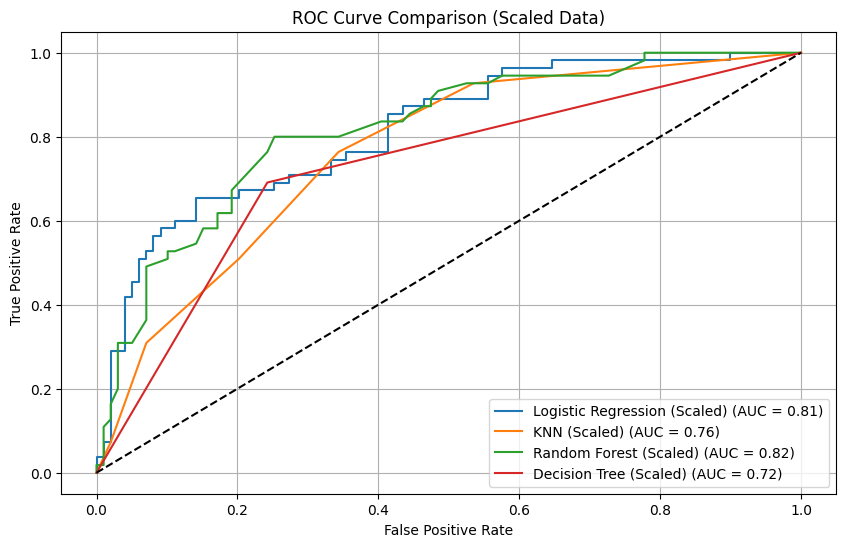

In [ ]:
# Plot ROC curves for scaled data
plt.figure(figsize=(10, 6))
for name, (model, _) in results_scaled.items():
    y_prob_scaled = model.predict_proba(X_test_scaled)[:, 1]
    fpr_scaled, tpr_scaled, _ = roc_curve(y_test, y_prob_scaled)
    auc_score_scaled = roc_auc_score(y_test, y_prob_scaled)
    plt.plot(fpr_scaled, tpr_scaled, label=f"{name} (AUC = {auc_score_scaled:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Scaled Data)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import pandas as pd

# Function to extract metrics from classification report
def extract_metrics(report):
    lines = report.split('\n')
    metrics = {}
    for line in lines[2:4]: # Extract metrics for class 0 and 1
        parts = line.split()
        if len(parts) > 0:
            label = parts[0]
            metrics[f'{label}_precision'] = float(parts[1])
            metrics[f'{label}_recall'] = float(parts[2])
            metrics[f'{label}_f1-score'] = float(parts[3])
    accuracy_line = lines[5].split()
    metrics['accuracy'] = float(accuracy_line[1])
    return metrics

# Create a dictionary to store metrics before and after scaling
comparison_data = {}

# Extract metrics for original models
print("--- Original Model Metrics ---")
for name, (model, y_pred) in results.items():
    report = classification_report(y_test, y_pred)
    print(f"\n{name}:\n{report}")
    metrics = extract_metrics(report)
    # Calculate AUC for original models
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics['auc'] = roc_auc_score(y_test, y_prob)
    comparison_data[name + ' (Original)'] = metrics

# Extract metrics for scaled models
print("\n--- Scaled Model Metrics ---")
for name, (model, y_pred_scaled) in results_scaled.items():
    report_scaled = classification_report(y_test, y_pred_scaled)
    print(f"\n{name}:\n{report_scaled}")
    metrics_scaled = extract_metrics(report_scaled)
     # Calculate AUC for scaled models
    y_prob_scaled = model.predict_proba(X_test_scaled)[:, 1]
    metrics_scaled['auc'] = roc_auc_score(y_test, y_prob_scaled)
    comparison_data[name] = metrics_scaled


# Create a pandas DataFrame from the comparison data
comparison_df = pd.DataFrame.from_dict(comparison_data, orient='index')

# Reorder columns for better readability
ordered_columns = []
for metric_type in ['precision', 'recall', 'f1-score']:
    for label in ['0', '1']:
        ordered_columns.append(f'{label}_{metric_type}')
ordered_columns.extend(['accuracy', 'auc'])

comparison_df = comparison_df[ordered_columns]

# Display the comparison table
print("\n--- Model Performance Comparison (Before and After Scaling) ---")
display(comparison_df)

--- Original Model Metrics ---

Logistic Regression:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154


KNN:
              precision    recall  f1-score   support

           0       0.75      0.71      0.73        99
           1       0.52      0.58      0.55        55

    accuracy                           0.66       154
   macro avg       0.64      0.64      0.64       154
weighted avg       0.67      0.66      0.67       154


Random Forest:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        99
           1       0.62      0.65      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154

,0_precision,1_precision,0_recall,1_recall,0_f1-score,1_f1-score,accuracy,auc
Logistic Regression (Original),0.81,0.64,0.79,0.67,0.80,0.65,0.75,0.812856
KNN (Original),0.75,0.52,0.71,0.58,0.73,0.55,0.66,0.720110
Random Forest (Original),0.80,0.62,0.78,0.65,0.79,0.64,0.73,0.815978
Decision Tree (Original),0.83,0.61,0.74,0.73,0.78,0.66,0.73,0.732323
Logistic Regression (Scaled),0.81,0.65,0.80,0.67,0.81,0.66,0.75,0.814692
KNN (Scaled),0.75,0.58,0.80,0.51,0.77,0.54,0.69,0.764096
Random Forest (Scaled),0.82,0.66,0.81,0.67,0.81,0.67,0.76,0.816896
Decision Tree (Scaled),0.82,0.61,0.76,0.69,0.79,0.65,0.73,0.724242


# Decision

Given the critical nature of minimizing false negatives in diabetes detection, the Decision Tree (Scaled) might be a strong choice due to its highest recall. However, if you also need to keep false positives relatively low, the Random Forest (Scaled) offers a better balance of high recall and precision.

Ultimately, the "best" model depends on the specific clinical implications and the acceptable levels of false positives and false negatives.